# Notebook 7: Isolation-with-Migration (IM)-modellen

I denne notebook implementerer og analyserer jeg **Isolation-with-Migration (IM)**-modellen via phasics epoch-baserede tilgang (`add_epoch`). IM-modellen er en tidsindhomogen udvidelse af two-island modellen, der tilføjer et split-tidspunkt $t_s$, som deler populationernes historie i to epoker:

- **Epoke 0** ($0 \to t_s$): To separate populationer med størrelser $N_1$ og $N_2$ og symmetrisk migration med rate $m$
- **Epoke 1** ($t_s \to \infty$): Én fælles ancestral population med størrelse $N_a$ og ingen migration

Epoch-konstruktionen følger vejlederens kode direkte: callback-funktionen `im_two_epoch` definerer overgange per epoke via `epoch_idx`-parameteren, og `add_epoch` udvider grafen ved at beregne stop-sandsynligheder ved $t_s$ og tilføje kanter til epoke-1 tilstandene.

**Parametervektoren:** `theta = [1/N1, 1/N2, m, 1/Na, epoch_trans_rate]`  
Indekserne matcher `coeff[idx]` i callback: pop-1 koalescens bruger `coeff[0]`, pop-2 bruger `coeff[1]`, migration bruger `coeff[2]`, ancestral koalescens bruger `coeff[3]`. Den sidste koefficient (`coeff[-1]`) styres internt af `add_epoch`.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property,
    clear_caches,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

%config InlineBackend.figure_format = 'svg'
np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 4)

## Tilstandsrum og callback-funktion

Vejlederens `add_epoch`-mønster kræver:

1. `StateIndexer` med et `slots=['epoch']`-slot der holder epoke-nummeret som en del af tilstandsvektoren
2. Callback-funktionen modtager `epochs`, `epoch_idx` og `indexer` som keyword-argumenter og returnerer kun overgange hvis `state[indexer.epoch] == epoch_idx`
3. Koefficient-vektoren har `len(epochs) + 1` elementer: ét per epoke plus ét til epoch-transition-raten (som `add_epoch` udfylder)

For IM-modellen bruger vi:
- `ton`: antal efterkommere (1 til $n$)
- `pop`: population (1 eller 2)
- `epoch`-slot: 0 (migrationsfase) eller 1 (ancestral)

Starttilstanden for $n=4$ (2 linjer i pop1, 2 linjer i pop2) er epoke 0.

In [2]:
nr_samples = 4
epochs     = [1.0]  # t_s = 1.0; ændres per kald via build_im_graph

indexer = StateIndexer(
    lineages=[
        Property('ton', min_value=1, max_value=nr_samples),
        Property('pop', min_value=1, max_value=2),
    ],
    slots=['epoch']
)

# Starttilstand: 2 singletons i pop1, 2 singletons i pop2, epoke 0
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(ton=1, pop=1)] = 2
ipv[indexer.lineages.props_to_index(ton=1, pop=2)] = 2
ipv[indexer.epoch] = 0

print("Starttilstand:", ipv)
print("Tilstandslængde:", indexer.state_length)
print(f"Koefficient-dimensioner: len(epochs)+1 = {len(epochs)+1}")
print("Layout: [1/N1, 1/N2, m, 1/Na, epoch_trans_rate]")

Starttilstand: [2, 0, 0, 0, 2, 0, 0, 0, 0]
Tilstandslængde: 9
Koefficient-dimensioner: len(epochs)+1 = 2
Layout: [1/N1, 1/N2, m, 1/Na, epoch_trans_rate]


In [3]:
def im_two_epoch(state, epochs=None, epoch_idx=None, indexer=None):
    """
    IM-model callback. Følger din NB5-mønster direkte.

    coeff-layout: [1/N1, 1/N2, m, 1/Na, epoch_trans_rate]
      coeff[0] = 1/N1  (koalescens i pop1, epoke 0)
      coeff[1] = 1/N2  (koalescens i pop2, epoke 0)
      coeff[2] = m     (migration, epoke 0)
      coeff[3] = 1/Na  (koalescens, epoke 1)
      coeff[4] = epoch-transition-rate (udfyldes af add_epoch)
    """
    transitions = []
    epoch_idx   = int(epoch_idx)
    N_PARAMS    = 5  # [1/N1, 1/N2, m, 1/Na, epoch_trans]

    # Kun overgange for den aktuelle epoke
    if state[indexer.epoch] != epoch_idx:
        return transitions

    # state.sum() inkluderer epoch-slot (0 eller 1), men er tilstrækkeligt
    # som check -- bruges direkte som i NB5
    if state.sum() <= 1:
        return transitions

    # --- Koalescens: kun inden for samme population ---
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)

        if pi.pop != pj.pop:
            continue

        same = int(pi.ton == pj.ton)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue

        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        k = indexer.lineages.props_to_index(ton=pi.ton + pj.ton, pop=pi.pop)
        new[k] += 1

        coeff = np.zeros(N_PARAMS)
        rate  = state[i] * (state[j] - same) / (1 + same)

        if epoch_idx == 0:
            # pop=1 -> theta[0]=1/N1;  pop=2 -> theta[1]=1/N2
            coeff[pi.pop - 1] = rate
        elif epoch_idx == 1:
            # Ancestral population -> theta[3]=1/Na
            coeff[3] = rate

        transitions.append([new, coeff])

    # --- Migration: kun i epoke 0 ---
    if epoch_idx == 0:
        for i in range(indexer.lineages.state_length):
            if state[i] < 1:
                continue
            pi        = indexer.lineages.index_to_props(i)
            other_pop = 2 if pi.pop == 1 else 1
            j         = indexer.lineages.props_to_index(ton=pi.ton, pop=other_pop)
            new       = state.copy()
            new[i]   -= 1
            new[j]   += 1
            coeff     = np.zeros(N_PARAMS)
            coeff[2]  = state[i]  # theta[2] = m
            transitions.append([new, coeff])

    return transitions

In [4]:
def add_epoch(graph, callback, epochs, epoch_idx, indexer):
    """
    Udvid grafen med epoke epoch_idx.
    Følger din NB5-implementation direkte:
    - Iterer over alle vertices fra epoke (epoch_idx-1)
    - Tilføj kant til søster-tilstand i epoke epoch_idx med coeff[-1] = 1.0
    - Kald graph.extend() med callback for den nye epoke
    """
    N_PARAMS = 5  # [1/N1, 1/N2, m, 1/Na, epoch_trans]

    for v_idx in range(1, graph.vertices_length()):
        vertex = graph.vertex_at(v_idx)
        state  = vertex.state()

        # Kun vertices fra den foregående epoke
        if state[indexer.epoch] != epoch_idx - 1:
            continue

        # Søster-tilstand i den nye epoke
        sister_state                = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child                       = graph.find_or_create_vertex(sister_state)

        # Epoch-transition-rate i den sidst koefficient
        coeff      = np.zeros(N_PARAMS)
        coeff[-1]  = 1.0  # skaleres via theta[4] i update_weights
        vertex.add_edge(child, coeff)

    # Udvid grafen med callback for den nye epoke
    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)

In [5]:
def build_im_graph(t_s, N1, N2, m, Na):
    """
    Byg IM-graf med add_epoch-mønsteret fra NB5.

    theta = [1/N1, 1/N2, m, 1/Na, epoch_trans_rate]

    epoch_trans_rate sættes til 1/t_s: dette skalerer kanten fra
    epoke-0 tilstande til epoke-1 tilstande, så overgangen sker
    med den korrekte rate svarende til split-tidspunktet t_s.
    """
    epochs_ts = [t_s]
    # theta[4] = 1/t_s: epoch-transition-raten
    theta     = [1/N1, 1/N2, m, 1/Na, 1/t_s]

    # Byg epoke-0 grafen
    graph = Graph(
        im_two_epoch,
        ipv=ipv,
        epochs=epochs_ts,
        epoch_idx=0,
        indexer=indexer,
    )
    graph.update_weights(theta)

    # Tilføj epoke 1 (ancestral population)
    add_epoch(graph, im_two_epoch, epochs_ts, epoch_idx=1, indexer=indexer)
    graph.update_weights(theta)

    return graph


# --- Verificering mod kendte grænser ---
print("=== Verificering ===")
print(f"{'t_s':<8} {'E[TMRCA]':<14} {'Var[TMRCA]':<14} {'tilstande'}")
print("-" * 50)
for t_s_test in [0.1, 0.5, 1.0, 2.0, 5.0]:
    g = build_im_graph(t_s=t_s_test, N1=1.0, N2=1.0, m=1.0, Na=2.0)
    print(f"{t_s_test:<8.1f} {g.expectation():<14.4f} {g.variance():<14.4f} {g.vertices_length()}")

=== Verificering ===
t_s      E[TMRCA]       Var[TMRCA]     tilstande
--------------------------------------------------
0.1      2.8463         4.8814         41
0.5      2.6524         4.4582         41
1.0      2.7206         4.0791         41
2.0      3.2438         5.0168         41
5.0      5.6899         22.3473        41


Tilstandsrum (n=2 startpunkt, to epoker): 11 tilstande


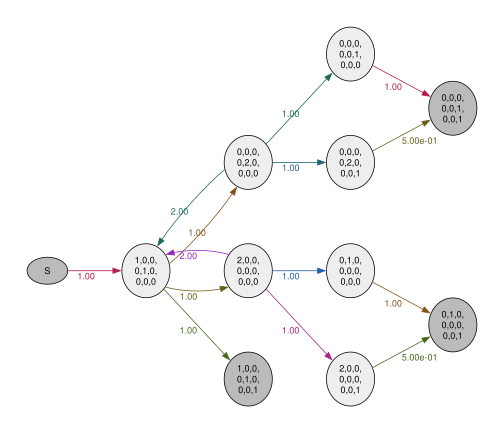

In [6]:
# Visualisér tilstandsrummet for n=2 (kun epoke 0, overskuelig)
# Bruger build_im_graph med lille n ved at ændre ipv midlertidigt

ipv_small  = [0] * indexer.state_length
ipv_small[indexer.lineages.props_to_index(ton=1, pop=1)] = 1
ipv_small[indexer.lineages.props_to_index(ton=1, pop=2)] = 1
ipv_small[indexer.epoch] = 0

theta_vis = [1.0, 1.0, 1.0, 0.5, 1.0]

g_vis = Graph(
    im_two_epoch,
    ipv=ipv_small,
    epochs=[1.0],
    epoch_idx=0,
    indexer=indexer,
)
g_vis.update_weights(theta_vis)
add_epoch(g_vis, im_two_epoch, [1.0], epoch_idx=1, indexer=indexer)
g_vis.update_weights(theta_vis)

print(f"Tilstandsrum (n=2 startpunkt, to epoker): {g_vis.vertices_length()} tilstande")
g_vis.plot()

## E[TMRCA] som funktion af $t_s$ og $m$

Split-tidspunktet $t_s$ bestemmer, hvornår de to populationer ophørte med at udveksle gener. For $t_s \to 0$ er migrationsfasen kortvarig og modellen domineres af den ancestrale population ($N_a$). For $t_s \to \infty$ dominerer migrationsfasen, og modellen nærmer sig two-island.

### Hypotese
- For lav migration er E[TMRCA] **voksende** i $t_s$: migrationsfasen er den "langsomme" kanal (lav $m$ = sjælden koalescens), så jo længere den varer, jo større E[TMRCA]. For høj migration er E[TMRCA] næsten flad i $t_s$.

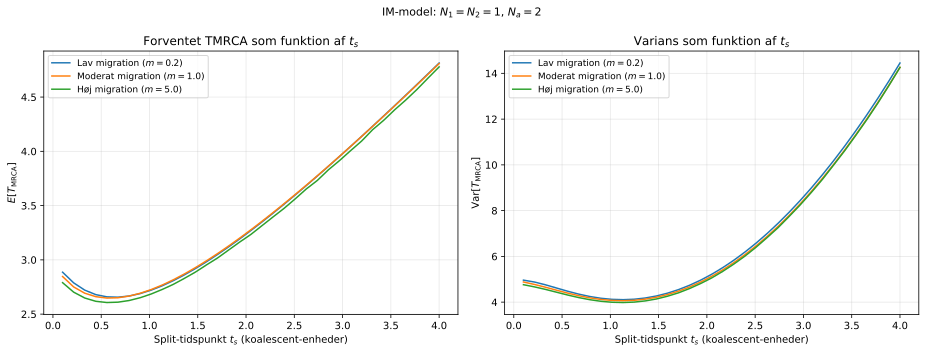

In [7]:
t_s_values = np.linspace(0.1, 4.0, 35)

migration_scenarios = [
    {'label': 'Lav migration ($m=0.2$)',     'm': 0.2},
    {'label': 'Moderat migration ($m=1.0$)', 'm': 1.0},
    {'label': 'Høj migration ($m=5.0$)',     'm': 5.0},
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for sc in migration_scenarios:
    E_vals, Var_vals = [], []
    for t_s in t_s_values:
        g = build_im_graph(t_s=t_s, N1=1.0, N2=1.0, m=sc['m'], Na=2.0)
        E_vals.append(g.expectation())
        Var_vals.append(g.variance())
    axes[0].plot(t_s_values, E_vals,   label=sc['label'])
    axes[1].plot(t_s_values, Var_vals, label=sc['label'])

for ax in axes:
    ax.set_xlabel('Split-tidspunkt $t_s$ (koalescent-enheder)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[0].set_ylabel('$E[T_{\\mathrm{MRCA}}]$')
axes[1].set_ylabel('$\\mathrm{Var}[T_{\\mathrm{MRCA}}]$')
axes[0].set_title('Forventet TMRCA som funktion af $t_s$')
axes[1].set_title('Varians som funktion af $t_s$')
plt.suptitle('IM-model: $N_1=N_2=1$, $N_a=2$', fontsize=11)
plt.tight_layout(); plt.show()

## Sammenligning: two-island vs IM og konvergens med $t_s$

IM-modellen reduceres til two-island for $t_s \to \infty$. Jeg finder det $t_s$ ved hvilket de to modeller er inden for 5% i E[TMRCA], og undersøger om Var[TMRCA] adskiller dem selv når E er ens.

### Hypotese
- For moderat migration konvergerer E[TMRCA] til two-island inden for 5% ved $t_s \approx 2$–$3$. Var[TMRCA] er derimod forskellig for alle endelige $t_s$ fordi epoke-overgangen tilføjer ekstra variation.

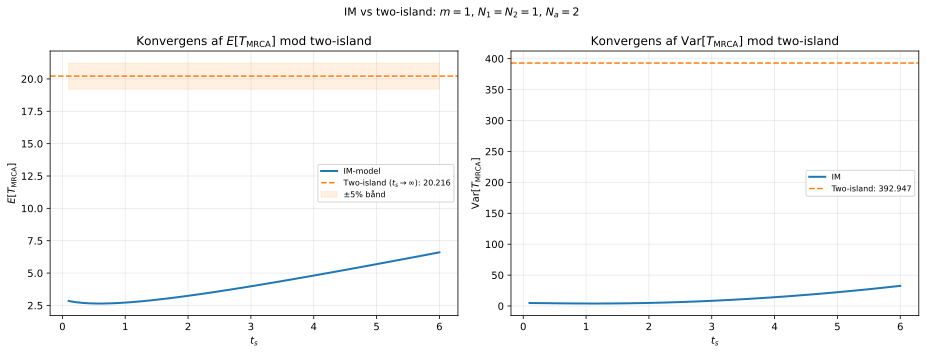

E[TMRCA] inden for 5% af two-island ved t_s ≈ 0.10
Var-forskel ved dette t_s: 388.0658


In [8]:
# Two-island reference: IM med stort t_s
g_ref  = build_im_graph(t_s=20.0, N1=1.0, N2=1.0, m=1.0, Na=2.0)
E_ref  = g_ref.expectation()
Var_ref = g_ref.variance()

t_s_sweep = np.linspace(0.1, 6.0, 55)
E_im, Var_im = [], []
for t_s in t_s_sweep:
    g = build_im_graph(t_s=t_s, N1=1.0, N2=1.0, m=1.0, Na=2.0)
    E_im.append(g.expectation())
    Var_im.append(g.variance())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t_s_sweep, E_im, lw=2, label='IM-model')
axes[0].axhline(E_ref, color='C1', linestyle='--', label=f'Two-island ($t_s\\to\\infty$): {E_ref:.3f}')
axes[0].fill_between(t_s_sweep, E_ref*0.95, E_ref*1.05, alpha=0.12, color='C1', label='±5% bånd')
axes[0].set_xlabel('$t_s$'); axes[0].set_ylabel('$E[T_{\\mathrm{MRCA}}]$')
axes[0].set_title('Konvergens af $E[T_{\\mathrm{MRCA}}]$ mod two-island')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(t_s_sweep, Var_im, lw=2, label='IM')
axes[1].axhline(Var_ref, color='C1', linestyle='--', label=f'Two-island: {Var_ref:.3f}')
axes[1].set_xlabel('$t_s$'); axes[1].set_ylabel('$\\mathrm{Var}[T_{\\mathrm{MRCA}}]$')
axes[1].set_title('Konvergens af $\\mathrm{Var}[T_{\\mathrm{MRCA}}]$ mod two-island')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('IM vs two-island: $m=1$, $N_1=N_2=1$, $N_a=2$', fontsize=11)
plt.tight_layout(); plt.show()

diffs = np.abs(np.array(E_im) - E_ref) / E_ref
idx   = np.argmax(diffs < 0.05)
print(f"E[TMRCA] inden for 5% af two-island ved t_s ≈ {t_s_sweep[idx]:.2f}")
print(f"Var-forskel ved dette t_s: {abs(Var_im[idx]-Var_ref):.4f}")

## Forventede sojourn-tider per epoke

`expected_sojourn_time()` giver den forventede tid i hver tilstand. Ved at summere over tilstande med `state[indexer.epoch] == 0` vs `== 1` opdeles TMRCA i epoke-0 (migrationsfase) og epoke-1 (ancestral) bidrag.

### Hypotese
- For lav migration dominerer epoke 1: linjer koalescerer sjældent i migrationsfasen og venter i stedet til ancestral fasen. For høj migration dominerer epoke 0, og epoke-1-bidraget falder mod et minimum bestemt af $t_s$.

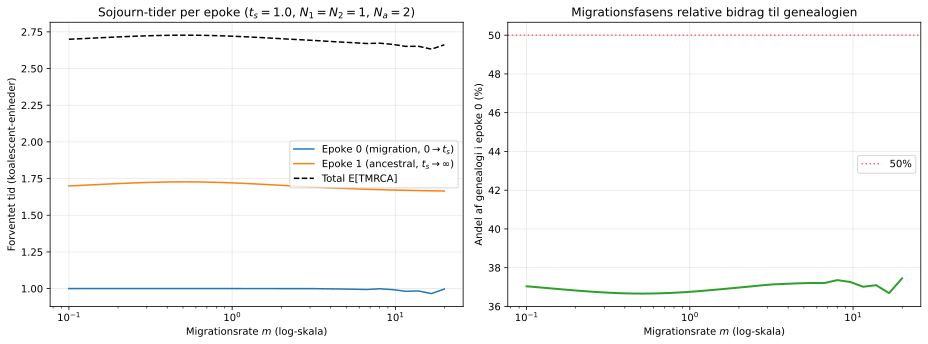

In [9]:
m_values  = np.logspace(-1, 1.3, 30)
t_s_fixed = 1.0
rows_soj  = []

for m in m_values:
    g       = build_im_graph(t_s=t_s_fixed, N1=1.0, N2=1.0, m=m, Na=2.0)
    sojourn = g.expected_sojourn_time()
    states  = g.states()

    E0 = sum(t for s, t in zip(states, sojourn) if int(s[indexer.epoch]) == 0)
    E1 = sum(t for s, t in zip(states, sojourn) if int(s[indexer.epoch]) == 1)

    rows_soj.append({
        'm': m,
        'E[T epoke 0]': E0,
        'E[T epoke 1]': E1,
        'E[TMRCA]':    E0 + E1,
        'Epoke-0 andel (%)': 100*E0/(E0+E1) if (E0+E1) > 0 else 0,
    })

df_soj = pd.DataFrame(rows_soj)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogx(df_soj['m'], df_soj['E[T epoke 0]'], label='Epoke 0 (migration, $0\\to t_s$)')
axes[0].semilogx(df_soj['m'], df_soj['E[T epoke 1]'], label='Epoke 1 (ancestral, $t_s\\to\\infty$)')
axes[0].semilogx(df_soj['m'], df_soj['E[TMRCA]'],     'k--', label='Total E[TMRCA]')
axes[0].set_xlabel('Migrationsrate $m$ (log-skala)')
axes[0].set_ylabel('Forventet tid (koalescent-enheder)')
axes[0].set_title(f'Sojourn-tider per epoke ($t_s={t_s_fixed}$, $N_1=N_2=1$, $N_a=2$)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogx(df_soj['m'], df_soj['Epoke-0 andel (%)'], color='C2', lw=2)
axes[1].axhline(50, color='red', linestyle=':', alpha=0.6, label='50%')
axes[1].set_xlabel('Migrationsrate $m$ (log-skala)')
axes[1].set_ylabel('Andel af genealogi i epoke 0 (%)')
axes[1].set_title('Migrationsfasens relative bidrag til genealogien')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## SFS under IM-modellen

SFS beregnes via Green-matricen $U = (-S)^{-1}$ og reward-vektorer der tæller $k$-ton linjer i begge observerede populationer. Signalet kombinerer epoke-0 (migration, populationsstruktur) og epoke-1 (ancestral demografisk signal).

### Hypotese
- Tidligt split (lille $t_s$): SFS domineres af ancestral population $\to$ flad. Sent split (stort $t_s$): stærkere singleton-signal fra migrationsfasens populationsstruktur.

In [ ]:
def im_sfs_reward(k, states, indexer):
    """Reward: antal linjer med præcis k ton i begge pop."""
    reward = np.zeros(len(states))
    for s_idx, s in enumerate(states):
        for pop in [1, 2]:
            lin_idx = indexer.lineages.props_to_index(ton=k, pop=pop)
            if lin_idx < indexer.lineages.size:
                reward[s_idx] += s[lin_idx]
    return reward


t_s_sfs_vals = [0.3, 1.0, 2.0, 5.0]
mu_sfs = 1.0
ks     = list(range(1, nr_samples))

fig, ax = plt.subplots(figsize=(8, 5))
for t_s in t_s_sfs_vals:
    g        = build_im_graph(t_s=t_s, N1=1.0, N2=1.0, m=1.0, Na=2.0)
    states_g = g.states()
    U        = g.green_matrix()
    alpha    = g.initial_distribution()

    sfs_vals = []
    for k in ks:
        r_k  = im_sfs_reward(k, states_g, indexer)
        E_Yk = float(alpha @ U @ r_k)
        sfs_vals.append(mu_sfs * E_Yk)

    ax.plot(ks, sfs_vals, 'o-', label=f'$t_s={t_s}$')

ax.set_xlabel('$k$')
ax.set_ylabel('$E[\\xi_k] \\cdot \\mu$')
ax.set_xticks(ks)
ax.set_xticklabels([f'{k}-ton' for k in ks])
ax.set_title('Forventet SFS: IM-model ($n=4$, $m=1$, $N_1=N_2=1$, $N_a=2$)')
ax.legend(title='Split-tidspunkt'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Konfundering af $t_s$ og $N_a$

Jeg visualiserer E[TMRCA] og Var[TMRCA] i $(t_s, 1/N_a)$-rummet som contour-plots. Horisontale konturer betyder perfekt konfundering (samme E for alle $t_s$ givet fast $1/N_a$); diagonale konturer betyder at parametrene er adskillelige.

### Hypotese
- E[TMRCA] er relativt flad langs diagonaler i $(t_s, 1/N_a)$-rummet: de to parametre er konfunderede for E. Var[TMRCA] bryder delvis symmetrien.

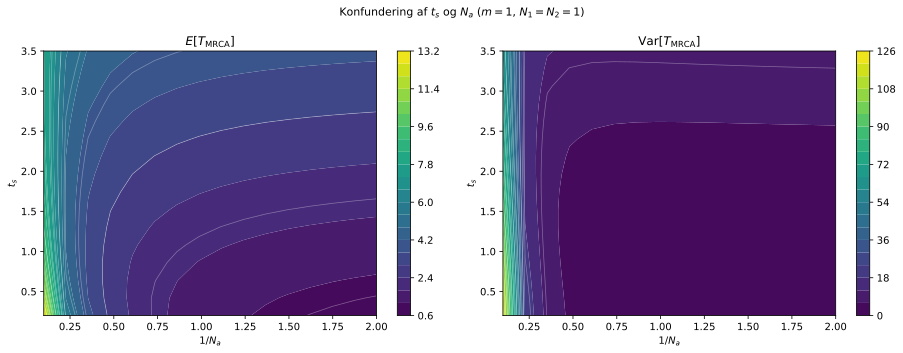

Horisontale konturer = konfundering; skæve konturer = delvis adskillelse


In [11]:
t_s_grid    = np.linspace(0.2, 3.5, 16)
inv_Na_grid = np.linspace(0.1, 2.0, 16)
E_grid      = np.zeros((len(t_s_grid), len(inv_Na_grid)))
Var_grid    = np.zeros_like(E_grid)

for i, t_s in enumerate(t_s_grid):
    for j, inv_Na in enumerate(inv_Na_grid):
        g              = build_im_graph(t_s=t_s, N1=1.0, N2=1.0, m=1.0, Na=1.0/inv_Na)
        E_grid[i, j]   = g.expectation()
        Var_grid[i, j] = g.variance()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, grid, title in zip(axes,
    [E_grid, Var_grid],
    ['$E[T_{\\mathrm{MRCA}}]$', '$\\mathrm{Var}[T_{\\mathrm{MRCA}}]$']):
    cf = ax.contourf(inv_Na_grid, t_s_grid, grid, levels=20, cmap='viridis')
    ax.contour(inv_Na_grid, t_s_grid, grid, levels=12, colors='white', alpha=0.35, linewidths=0.7)
    plt.colorbar(cf, ax=ax)
    ax.set_xlabel('$1/N_a$'); ax.set_ylabel('$t_s$'); ax.set_title(title)

plt.suptitle('Konfundering af $t_s$ og $N_a$ ($m=1$, $N_1=N_2=1$)', fontsize=11)
plt.tight_layout(); plt.show()
print("Horisontale konturer = konfundering; skæve konturer = delvis adskillelse")

## Bayesiansk inferens med SVGD

Jeg estimerer $m$ og $1/N_a$ med SVGD mens $N_1=N_2=1$ og $t_s$ fastholdes. `fixed` angiver indekser i den fulde theta-vektor `[1/N1, 1/N2, m, 1/Na, epoch_trans]`.

### Hypotese
- $m$ og $1/N_a$ er separabelt estimerbare for $n > 1000$. Posterioren viser negativ korrelation: høj $m$ kan delvist kompenseres af lav $1/N_a$.

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          Yes        1.0000     NA         NA         NA           NA          
1          Yes        1.0000     NA         NA         NA           NA          
2          No         3.0183     3.1794     1.0286     1.4287       5.0768      
3          No         0.4991     0.4992     0.0080     0.4874       0.5152      
4          Yes        1.0000     NA         NA         NA           NA          

Particles: 30, Iterations: 200


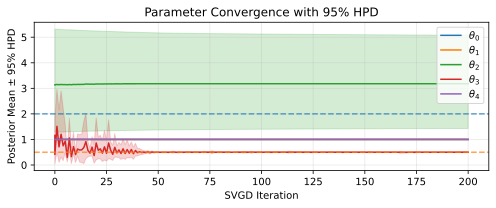

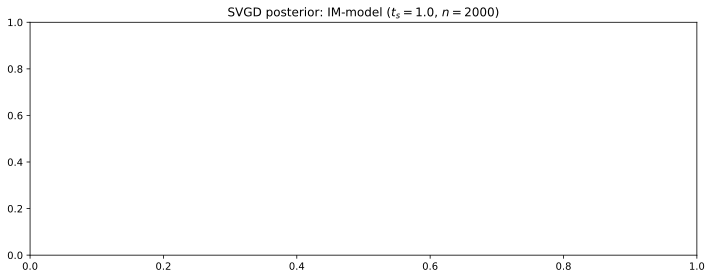

In [12]:
# Sande parametre
true_N1, true_N2, true_m, true_Na, true_t_s = 1.0, 1.0, 2.0, 2.0, 1.0

g_svgd = build_im_graph(t_s=true_t_s, N1=true_N1, N2=true_N2, m=true_m, Na=true_Na)
N_OBS  = 2000
obs    = g_svgd.sample(N_OBS)
print(f"Simulerede {N_OBS} obs. Mean TMRCA = {np.mean(obs):.3f}")

step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)

svgd_im = g_svgd.svgd(
    observed_data=obs,
    fixed=[
        (0, 1/true_N1),  # 1/N1
        (1, 1/true_N2),  # 1/N2
        (4, 1.0),        # epoch-transition-rate (intern)
    ],
    prior=[
        None,                        # 1/N1 (fixed)
        None,                        # 1/N2 (fixed)
        GaussPrior(ci=[0.5, 6.0]),  # m
        GaussPrior(ci=[0.1, 2.0]),  # 1/Na
        None,                        # epoch-rate (fixed)
    ],
    n_particles=30,
    n_iterations=200,
    learning_rate=step,
)

svgd_im.summary()
svgd_im.plot_ci(true_theta=[true_m, 1/true_Na])
plt.title(f'SVGD posterior: IM-model ($t_s={true_t_s}$, $n={N_OBS}$)')
plt.tight_layout(); plt.show()

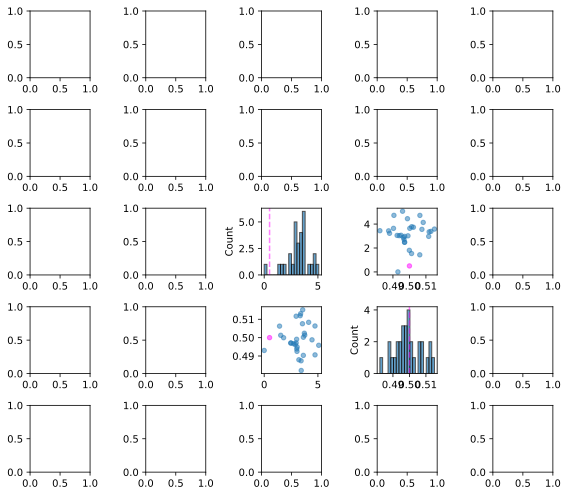

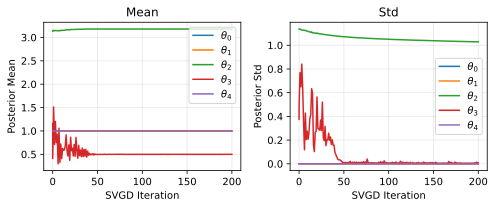

In [14]:
svgd_im.plot_pairwise(true_theta=[true_m, 1/true_Na])

svgd_im.plot_convergence()


## Sensitivitet over for fejlspecificeret $t_s$

### Hypotese
- Et for lille $t_s$ undervurderer migrationsfasens bidrag og giver for lille $m$ og for stor $N_a$. Et for stort $t_s$ giver den modsatte bias.

In [15]:
g_true_s = build_im_graph(t_s=1.0, N1=1.0, N2=1.0, m=2.0, Na=2.0)
obs_s    = g_true_s.sample(2000)

t_s_fits  = [0.3, 0.6, 1.0, 1.5, 2.5]
step_s    = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)
rows_s    = []

for t_s_fit in t_s_fits:
    g_fit = build_im_graph(t_s=t_s_fit, N1=1.0, N2=1.0, m=2.0, Na=2.0)
    sv = g_fit.svgd(
        observed_data=obs_s,
        fixed=[(0, 1.0), (1, 1.0), (4, 1.0)],
        prior=[None, None, GaussPrior(ci=[0.5, 6.0]), GaussPrior(ci=[0.1, 2.0]), None],
        n_particles=25, n_iterations=150, learning_rate=step_s,
    )
    rows_s.append({'t_s': t_s_fit,
                   'm mean': sv.mean()[0], 'm std': sv.std()[0],
                   '1/Na mean': sv.mean()[1], '1/Na std': sv.std()[1]})
    print(f"t_s={t_s_fit:.1f}: m={sv.mean()[0]:.3f}±{sv.std()[0]:.3f}, "
          f"1/Na={sv.mean()[1]:.3f}±{sv.std()[1]:.3f}")

df_s = pd.DataFrame(rows_s)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, param, true_val in zip(axes, ['m', '1/Na'], [2.0, 0.5]):
    ax.errorbar(df_s['t_s'], df_s[f'{param} mean'],
                yerr=df_s[f'{param} std']*1.96, fmt='o-', capsize=5)
    ax.axhline(true_val, color='red', linestyle='--', label=f'Sand={true_val}')
    ax.axvline(1.0, color='gray', linestyle=':', label='Sand $t_s=1.0$')
    ax.set_xlabel('Fittet $t_s$'); ax.set_ylabel(f'Estimeret ${param}$')
    ax.set_title(f'Bias i ${param}$'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Sensitivitet over for fejlspecificeret $t_s$', fontsize=11)
plt.tight_layout(); plt.show()

AttributeError: 'SVGD' object has no attribute 'mean'

## Prøvestørrelse og MoM vs SVGD

### Hypotese
- Posterior-bredden falder som $\sim 1/\sqrt{n}$. MoM-estimater er tæt på SVGD mean for $n > 2000$, men SVGD leverer usikkerhedskvantificering MoM ikke kan give.

In [ ]:
sample_sizes = [200, 500, 1000, 2000, 5000]
g_ss    = build_im_graph(t_s=1.0, N1=1.0, N2=1.0, m=2.0, Na=2.0)
step_ss = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)
rows_ss = []

for n in sample_sizes:
    obs_n = g_ss.sample(n)
    mom   = g_ss.method_of_moments(data=obs_n, fixed=[(0, 1.0), (1, 1.0), (4, 1.0)])
    sv    = g_ss.svgd(
        observed_data=obs_n,
        fixed=[(0, 1.0), (1, 1.0), (4, 1.0)],
        prior=[None, None, GaussPrior(ci=[0.5, 6.0]), GaussPrior(ci=[0.1, 2.0]), None],
        n_particles=25, n_iterations=150, learning_rate=step_ss,
    )
    rows_ss.append({'n': n,
                    'MoM m':       mom.theta[0] if mom else np.nan,
                    'MoM 1/Na':    mom.theta[1] if mom else np.nan,
                    'SVGD m mean': sv.mean()[0], 'SVGD m std': sv.std()[0],
                    'SVGD 1/Na mean': sv.mean()[1], 'SVGD 1/Na std': sv.std()[1]})
    print(f"n={n:5d}: m={sv.mean()[0]:.3f}±{sv.std()[0]:.3f}, "
          f"1/Na={sv.mean()[1]:.3f}±{sv.std()[1]:.3f}")

df_ss = pd.DataFrame(rows_ss)
n_arr = np.array(sample_sizes, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, param, true_val in zip(axes, ['m', '1/Na'], [2.0, 0.5]):
    ax.errorbar(df_ss['n'], df_ss[f'SVGD {param} mean'],
                yerr=df_ss[f'SVGD {param} std']*1.96, fmt='o-', capsize=4, label='SVGD')
    ax.plot(df_ss['n'], df_ss[f'MoM {param}'], 's--', label='MoM')
    ax.axhline(true_val, color='red', linestyle=':', label=f'Sand={true_val}')
    ax.set_xscale('log'); ax.set_xlabel('$n$ (log)')
    ax.set_ylabel(f'Estimeret ${param}$')
    ax.set_title(f'MoM vs SVGD: ${param}$')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Prøvestørrelse og MoM vs SVGD i IM-modellen', fontsize=11)
plt.tight_layout(); plt.show()